In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

df = pd.read_csv('Student_Performance.csv')

nan_counts = df.isnull().sum()
print("NaN counts:\n\n", nan_counts, "\n\n")

df.info()

NaN counts:

 Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64 


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [14]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


### EDA

In [15]:
df.drop_duplicates().info()

<class 'pandas.core.frame.DataFrame'>
Index: 9873 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     9873 non-null   int64  
 1   Previous Scores                   9873 non-null   int64  
 2   Extracurricular Activities        9873 non-null   object 
 3   Sleep Hours                       9873 non-null   int64  
 4   Sample Question Papers Practiced  9873 non-null   int64  
 5   Performance Index                 9873 non-null   float64
dtypes: float64(1), int64(4), object(1)
memory usage: 539.9+ KB


There are no NaN values in the dataset (so we not changing dataset here) and 127 duplicated entries in the dataset. Dropping duplicated entries. Let's as well rename columns and map Extracurricular Activities to 0-1 values. Other columns are already numerical.

In [16]:
df = df.drop_duplicates()

# Handle categorical variable
if 'Extracurricular Activities' in df.columns:
    df['Extracurricular Activities'] = df['Extracurricular Activities'].map({'Yes': 1, 'No': 0})
    
df = df.rename(columns={
    'Hours Studied': 'hours_studied',
    'Previous Scores': 'prev_scores',
    'Extracurricular Activities': 'extracurricular',
    'Sleep Hours': 'sleep_hours',
    'Sample Question Papers Practiced': 'papers_practiced',
    'Performance Index': 'target_score'
})

df.describe()

,hours_studied,prev_scores,extracurricular,sleep_hours,papers_practiced,target_score
count,9873.000000,9873.000000,9873.000000,9873.000000,9873.000000,9873.000000
mean,4.992100,69.441102,0.494986,6.531652,4.583004,55.216651
std,2.589081,17.325601,0.500000,1.697683,2.867202,19.208570
min,1.000000,40.000000,0.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,0.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,0.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,1.000000,8.000000,7.000000,70.000000
max,9.000000,99.000000,1.000000,9.000000,9.000000,100.000000


On average, students study for about 5 hours (ranging from 1 to 9) and get roughly 6.5 hours of sleep.

The previous scores are quite varied, with a mean of 69.4 and a wide range between 40 and 99.

About half of the students participate in extracurricular activities (as shown by the 0.49 mean in a binary column), and they practice an average of 4 to 5 sample papers.

The target ccore shows a distribution with a mean of 55.2, though it spans the full spectrum from a minimum of 10 to a perfect 100.

Overall, the data is clean with no missing values in these columns, and the standard deviations suggest there is enough variance to make this a great dataset for predictive modeling.

<Figure size 1000x800 with 0 Axes>

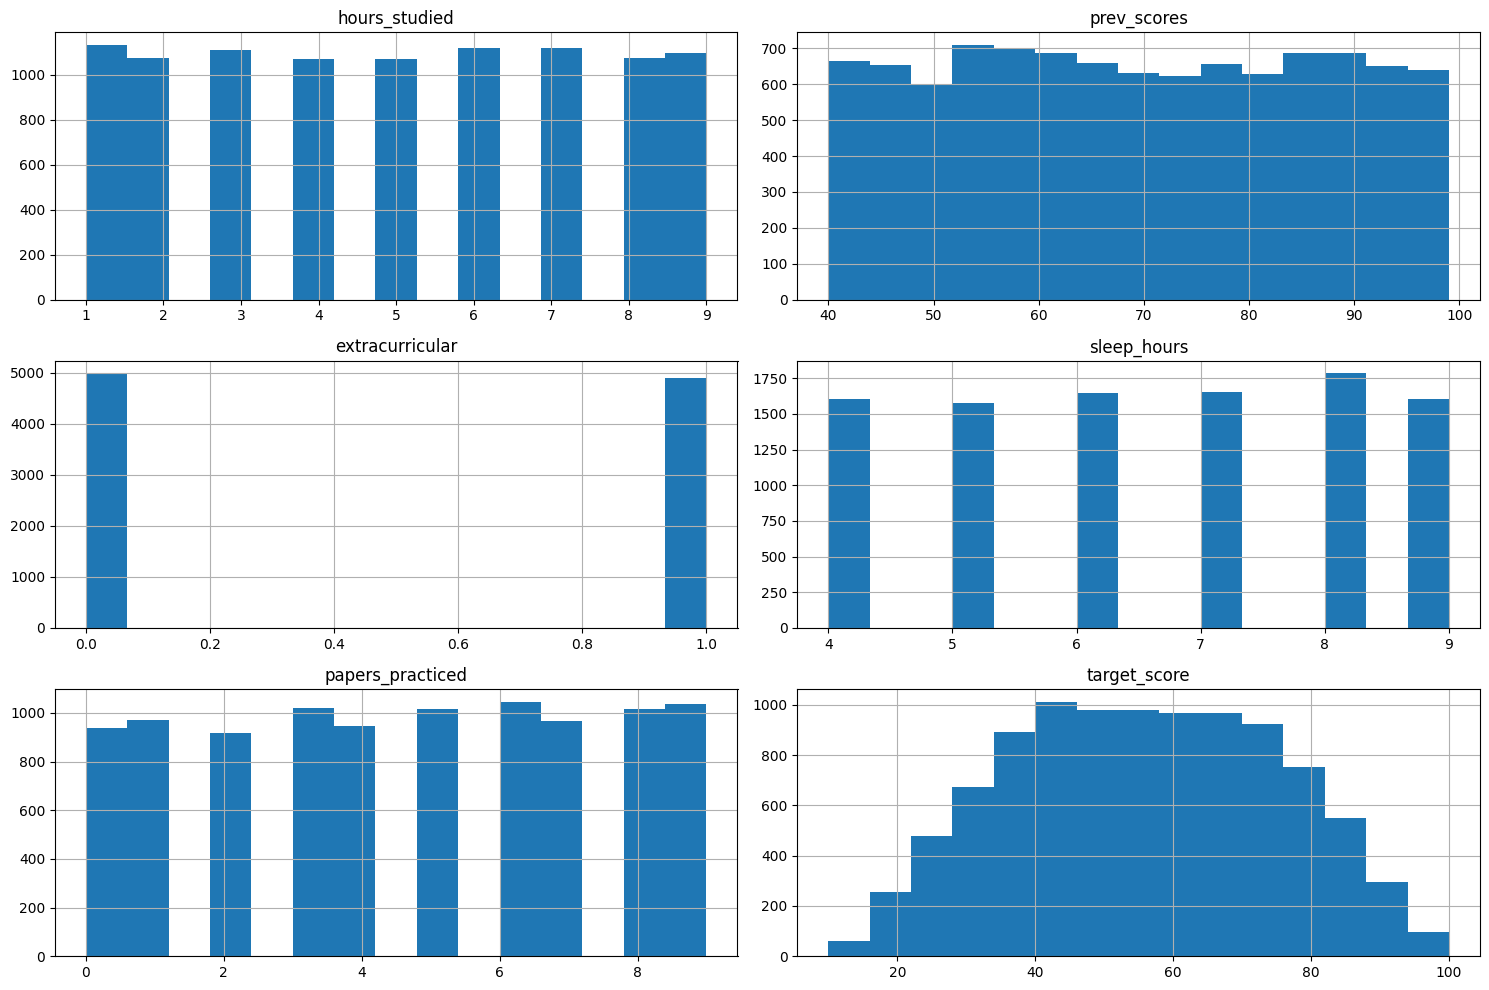

In [17]:
# Basic EDA plots

plt.figure(figsize=(10, 8))
df.hist(bins=15, figsize=(15, 10))
plt.tight_layout()
plt.show();

Looking at the histograms, we can see that most features like hours_studied, sleep_hours, and papers_practiced follow a uniform distribution, meaning the data is spread almost evenly across all possible values.

The extracurricular plot confirms a near-perfect split between students who participate and those who don't, while prev_scores shows a very consistent density across the 40–100 range. Interestingly, the target_score is the only variable showing a normal distribution, indicating that while the input factors are evenly distributed, the resulting performance tends to cluster around the 40–70 mark with fewer students at the extreme ends.

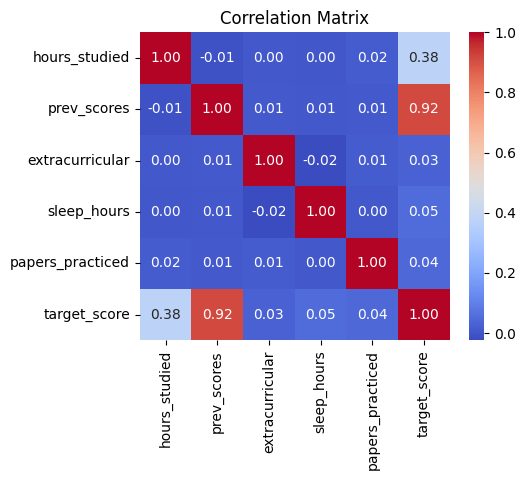

In [18]:
numeric_cols = df.select_dtypes(include=['int64', 'float64'])
plt.figure(figsize=(5, 4))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show();

The correlation matrix reveals a massive positive correlation (0.92) between prev_scores and target_score, suggesting that past academic performance is the strongest predictor of future results. There is also a moderate positive relationship (0.38) with hours_studied.

Interestingly, other factors like sleep_hours, extracurricular, and papers_practiced show almost zero correlation with the target, indicating they have very little linear impact on the final score in this specific dataset.

### Model training

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.decomposition import PCA

X = df.drop('target_score', axis=1)
y = df['target_score']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [21]:
# Normalization based on train mean and std
train_mean = X_train.mean()
train_std = X_train.std()

# Adding a small epsilon to std to avoid division by zero
X_train_norm = (X_train - train_mean) / (train_std + 1e-8)
X_val_norm = (X_val - train_mean) / (train_std + 1e-8)
X_test_norm = (X_test - train_mean) / (train_std + 1e-8)

In [39]:
# Helper function to print metrics
def calculate_metrics(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    header = f"{name} Metrics"
    print(header)
    print(f"{'MAE:':<6} {mae:>10.2f}")
    print(f"{'MSE:':<6} {mse:>10.2f}")
    print(f"{'RMSE:':<6} {rmse:>10.2f}")
    print(f"{'R2:':<6} {r2:>10.4f}")
    print("-" * 18)
    
    return mae, mse, rmse, r2


Depth 2:
Train Metrics
MAE:         7.30
MSE:        77.76
RMSE:        8.82
R2:        0.7901
------------------
Val Metrics
MAE:         7.32
MSE:        79.10
RMSE:        8.89
R2:        0.7808
------------------

Depth 3:
Train Metrics
MAE:         5.00
MSE:        37.86
RMSE:        6.15
R2:        0.8978
------------------
Val Metrics
MAE:         5.05
MSE:        38.62
RMSE:        6.21
R2:        0.8930
------------------

Depth 4:
Train Metrics
MAE:         3.93
MSE:        23.07
RMSE:        4.80
R2:        0.9377
------------------
Val Metrics
MAE:         3.96
MSE:        23.48
RMSE:        4.85
R2:        0.9349
------------------

Depth 5:
Train Metrics
MAE:         2.88
MSE:        12.89
RMSE:        3.59
R2:        0.9652
------------------
Val Metrics
MAE:         2.95
MSE:        13.30
RMSE:        3.65
R2:        0.9631
------------------


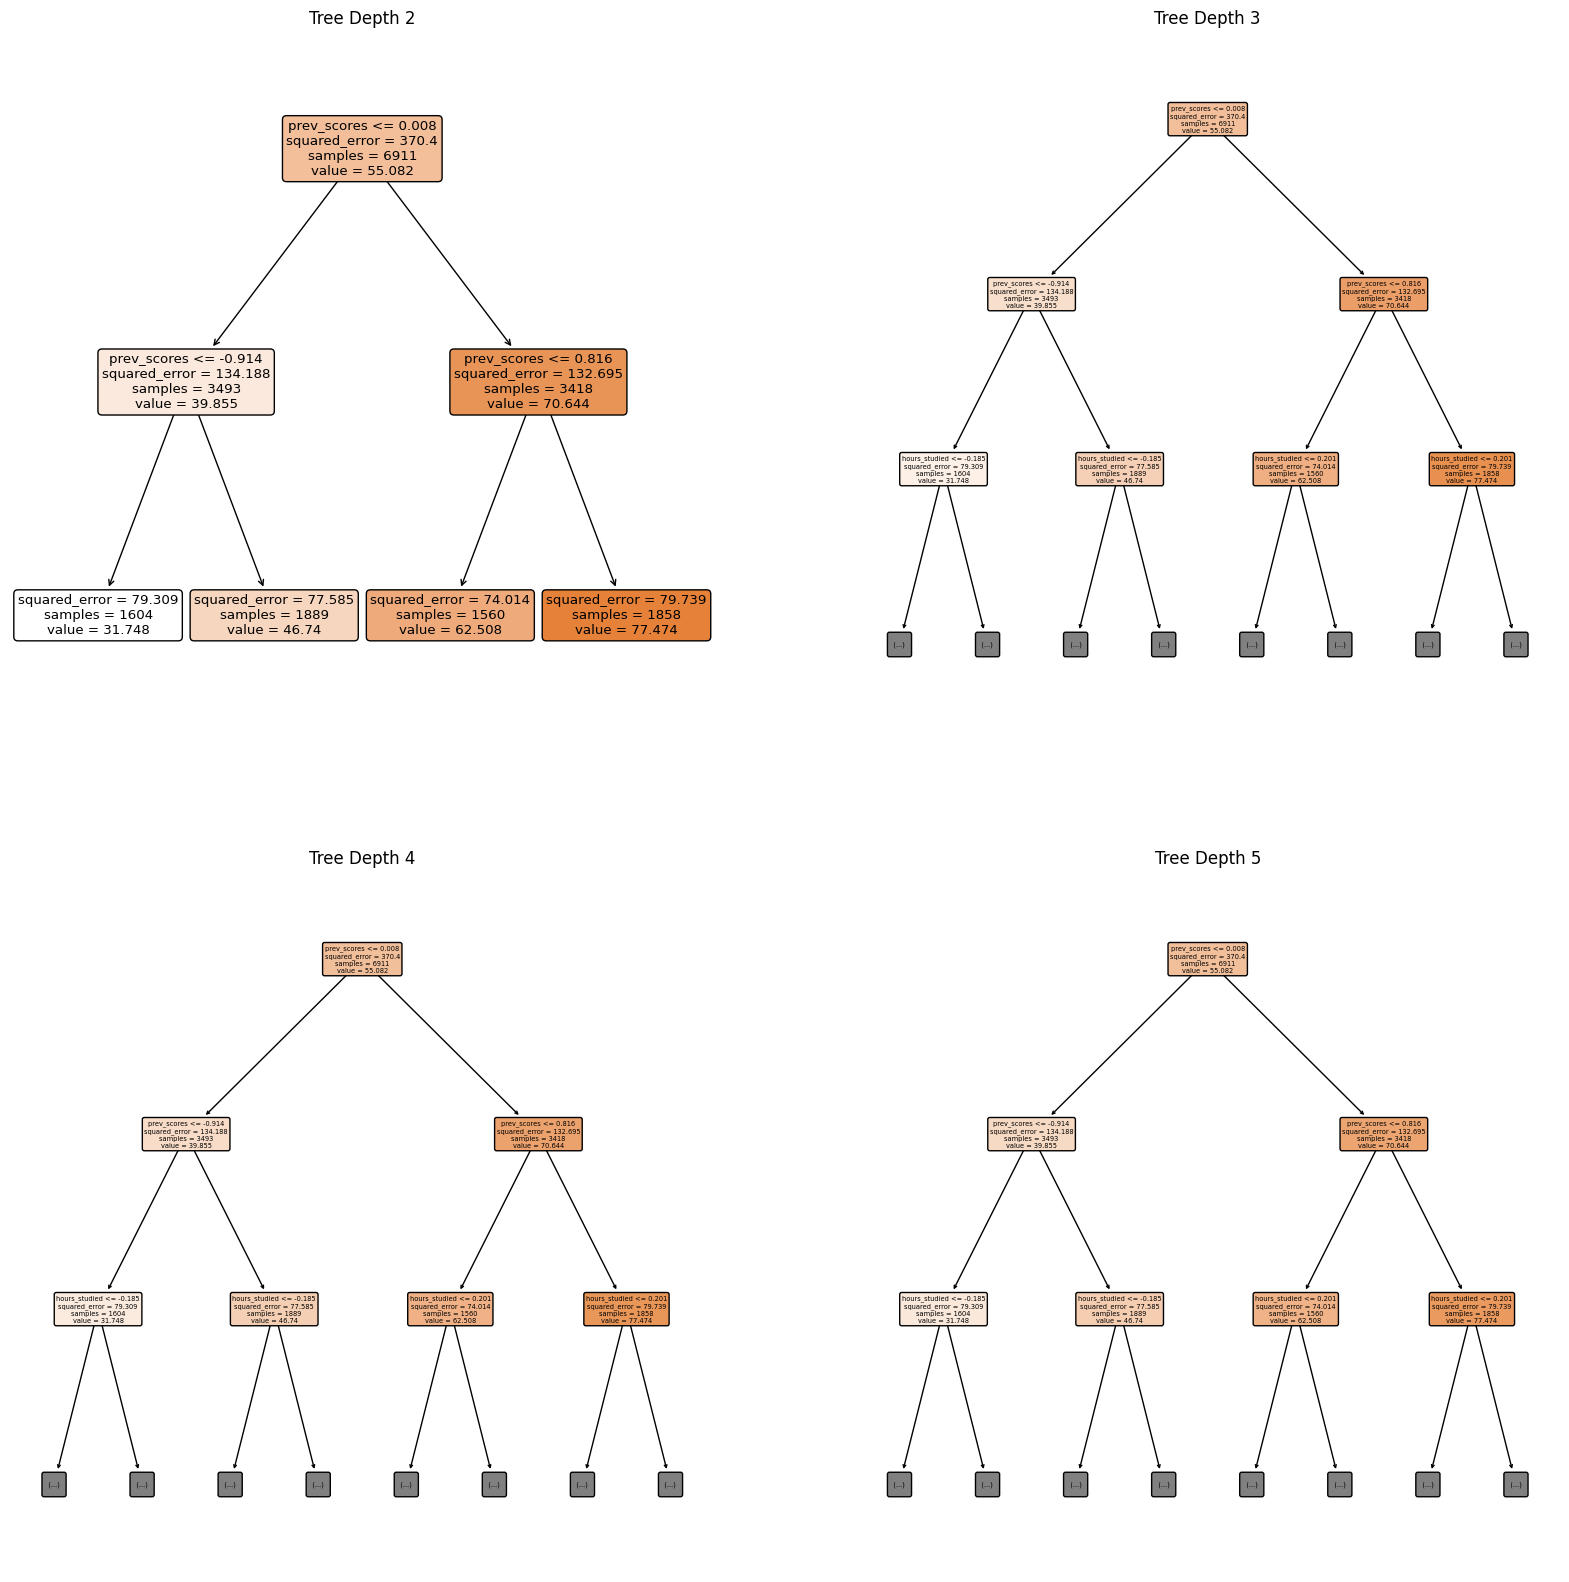

In [45]:
# sqrt(number of features) = sqrt(5) so optimally the max depth shouldn't be far from 2-3

depths = [2, 3, 4, 5]
trees = []
for d in depths:
    dt = DecisionTreeRegressor(max_depth=d, random_state=42)
    dt.fit(X_train_norm, y_train)
    trees.append(dt)
    
    print(f"\nDepth {d}:")
    y_pred_train = dt.predict(X_train_norm)
    calculate_metrics(y_train, y_pred_train, "Train")
    
    y_pred_val = dt.predict(X_val_norm)
    calculate_metrics(y_val, y_pred_val, "Val")

# Plot trees
plt.figure(figsize=(20, 20))
for i, dt in enumerate(trees):
    plt.subplot(2, 2, i+1)
    plot_tree(dt, feature_names=X.columns, filled=True, rounded=True, max_depth=2)
    plt.title(f"Tree Depth {depths[i]}")
plt.show()

Model demonstrates exceptional performance, reaching an $R^2$ of 0.96 at depth 5 without showing any signs of overfitting. Also we see prev_scores as the important feature as expected. The minimal gap between training and validation errors proves the tree is generalizing well to new data rather than just memorizing the training set. While initially we aimed for a shallower tree, the significant jump in accuracy from Depth 3 to Depth 5 suggests that the extra complexity is necessary to capture the strong influence of previous scores on student performance. Let's try deeper trees

In [47]:
depths = [6, 7, 8, 9, 10, 11]
trees = []
for d in depths:
    dt = DecisionTreeRegressor(max_depth=d, random_state=42)
    dt.fit(X_train_norm, y_train)
    trees.append(dt)
    
    print(f"\nDepth {d}:")
    y_pred_train = dt.predict(X_train_norm)
    calculate_metrics(y_train, y_pred_train, "Train")
    
    y_pred_val = dt.predict(X_val_norm)
    calculate_metrics(y_val, y_pred_val, "Val")


Depth 6:
Train Metrics
MAE:         2.40
MSE:         8.91
RMSE:        2.99
R2:        0.9759
------------------
Val Metrics
MAE:         2.46
MSE:         9.47
RMSE:        3.08
R2:        0.9738
------------------

Depth 7:
Train Metrics
MAE:         2.02
MSE:         6.40
RMSE:        2.53
R2:        0.9827
------------------
Val Metrics
MAE:         2.12
MSE:         7.04
RMSE:        2.65
R2:        0.9805
------------------

Depth 8:
Train Metrics
MAE:         1.78
MSE:         5.00
RMSE:        2.24
R2:        0.9865
------------------
Val Metrics
MAE:         2.00
MSE:         6.31
RMSE:        2.51
R2:        0.9825
------------------

Depth 9:
Train Metrics
MAE:         1.56
MSE:         3.87
RMSE:        1.97
R2:        0.9896
------------------
Val Metrics
MAE:         1.95
MSE:         5.96
RMSE:        2.44
R2:        0.9835
------------------

Depth 10:
Train Metrics
MAE:         1.32
MSE:         2.88
RMSE:        1.70
R2:        0.9922
------------------
Val Metrics


The best model is depth 9, as it achieves the lowest validation error (MAE of 1.95 and RMSE of 2.44) and the highest validation $R^2$ before the model begins to overfit. Beyond Depth 9, the training error continues to drop while the validation error starts to rise, indicating that deeper trees are simply memorizing noise rather than improving predictive accuracy.

Let's see its performance on the test set and if we are OK with it.

In [50]:
dt = DecisionTreeRegressor(max_depth=9, random_state=42)

dt.fit(X_train_norm, y_train)
    
y_pred_test = dt.predict(X_test_norm)
_ = calculate_metrics(y_test, y_pred_test, "Test")

Test Metrics
MAE:         2.08
MSE:         6.90
RMSE:        2.63
R2:        0.9813
------------------


Yes, metrics are still high quality, so we are staying on depth 9 and moving to the next part of the task

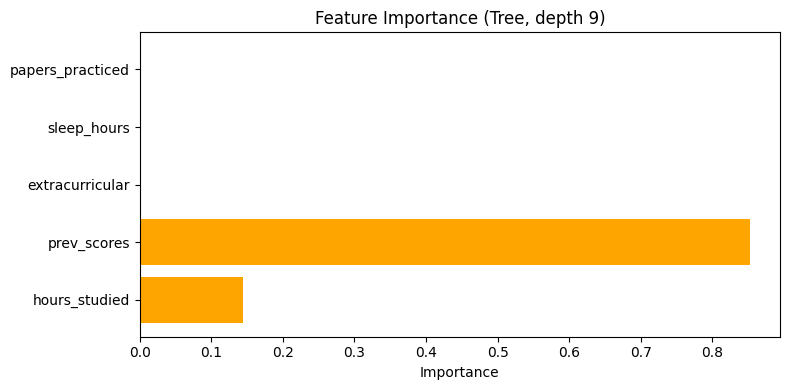

In [53]:
plt.figure(figsize=(8, 4))
plt.barh(X.columns, dt.feature_importances_, color='orange')
plt.title("Feature Importance (Tree, depth 9)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

As we can see only two features are really important here. Let's check the tree itself

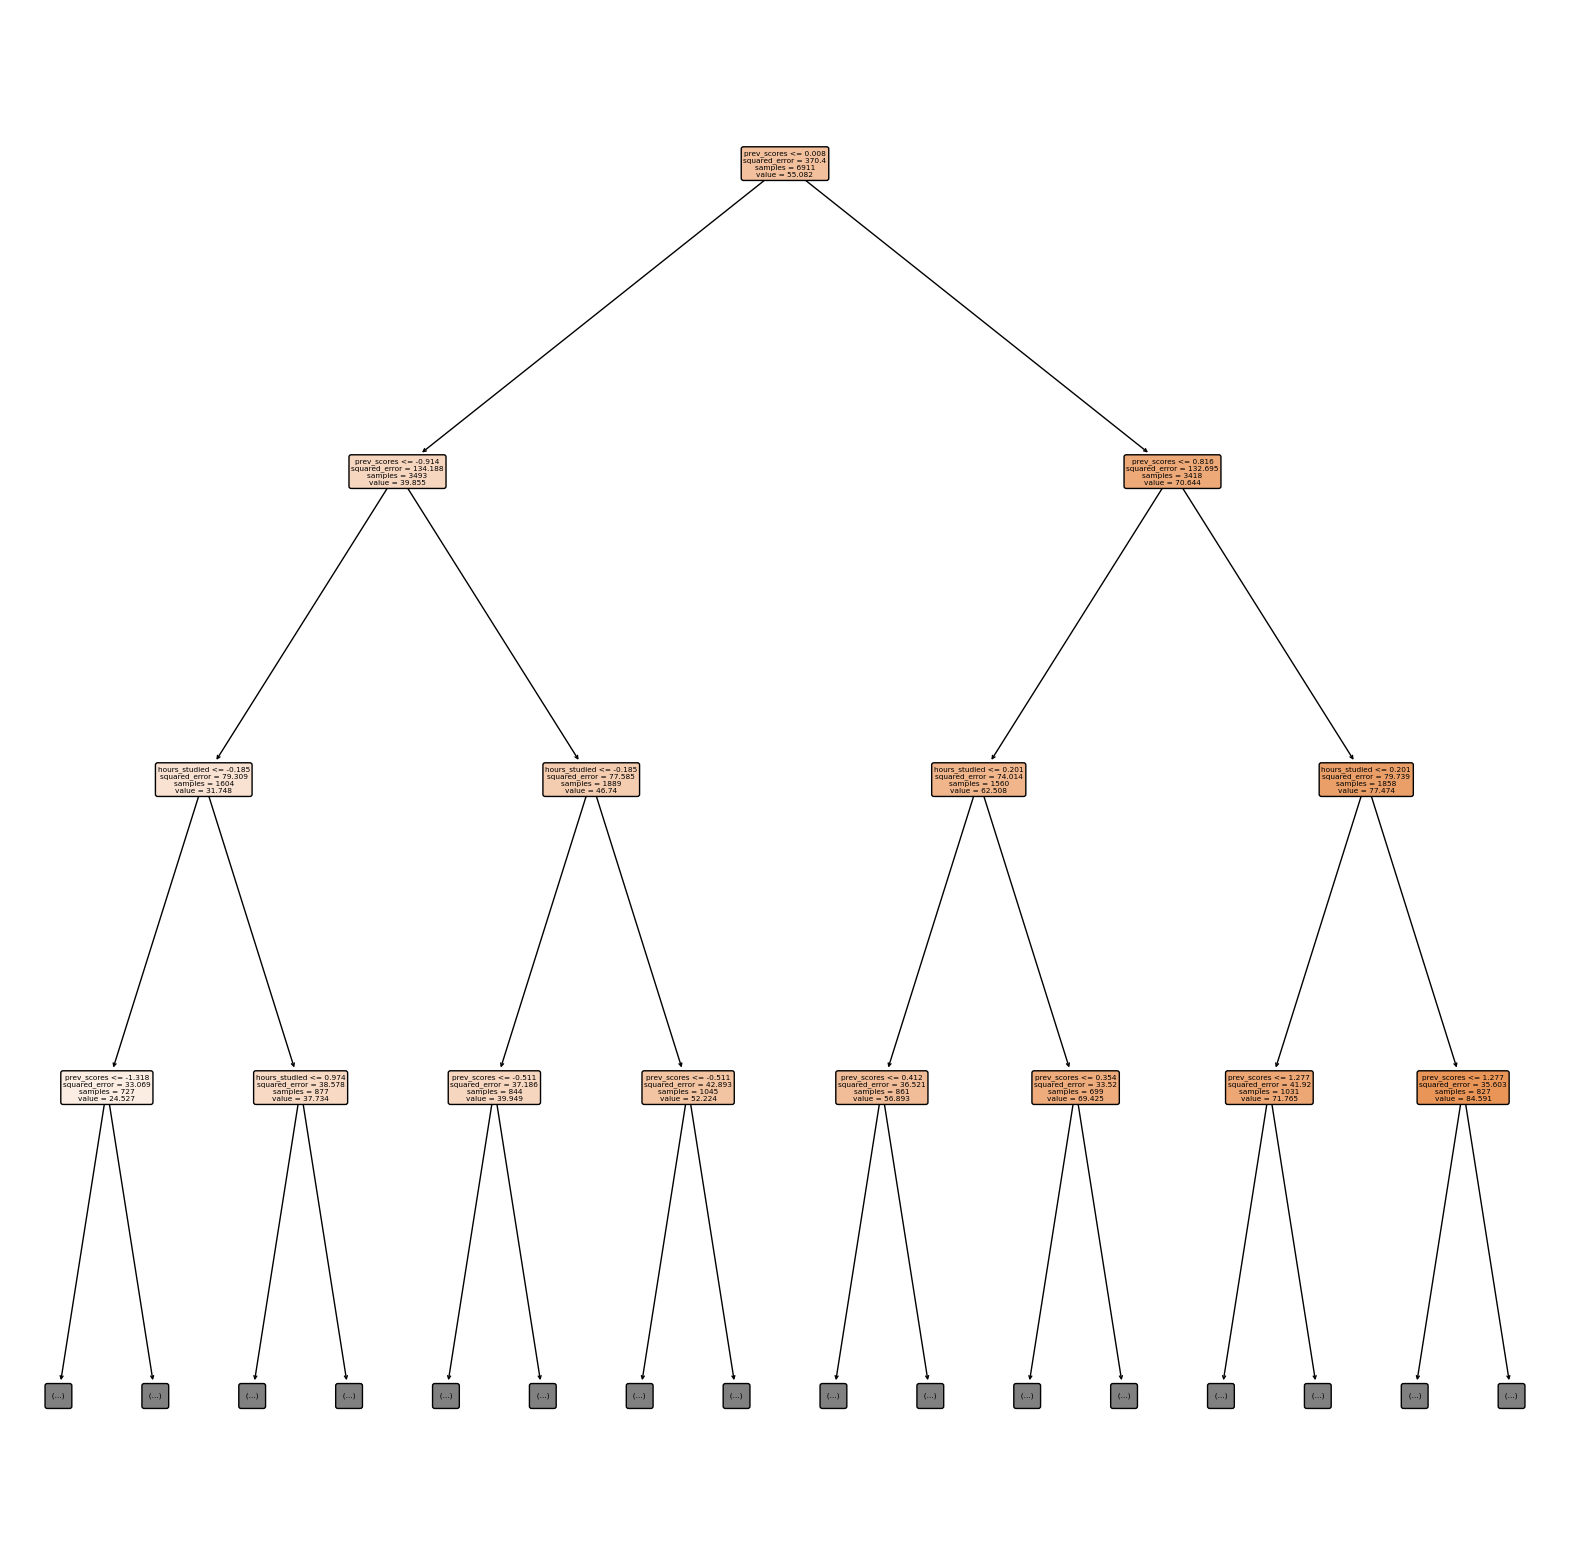

In [63]:
plt.figure(figsize=(20, 20))
plot_tree(dt, feature_names=X.columns, filled=True, rounded=True, max_depth=3);

Even though prev_scores and hours_studied carry almost all the predictive weight, the tree needs a depth of 9 to continuously slice those two variables into smaller, highly specific ranges. The deep tree isn't looking at new features, it is building a highly detailed, finely-tuned staircase out of two most important variables to squeeze out the lowest possible error.

In [51]:
# Noise

noise_train = np.random.uniform(-0.1, 0.1, size=X_train_norm.shape)
X_train_noisy = X_train_norm + noise_train

noise_val = np.random.uniform(-0.1, 0.1, size=X_val_norm.shape)
X_val_noisy = X_val_norm + noise_val

noise_test = np.random.uniform(-0.1, 0.1, size=X_test_norm.shape)
X_test_noisy = X_test_norm + noise_test

Noisy Tree Depth 7
Train Metrics
MAE:         2.10
MSE:         6.95
RMSE:        2.64
R2:        0.9812
------------------
Val Metrics
MAE:         2.37
MSE:         8.84
RMSE:        2.97
R2:        0.9755
------------------
Noisy Tree Depth 8
Train Metrics
MAE:         1.86
MSE:         5.39
RMSE:        2.32
R2:        0.9854
------------------
Val Metrics
MAE:         2.28
MSE:         8.22
RMSE:        2.87
R2:        0.9772
------------------
Noisy Tree Depth 9
Train Metrics
MAE:         1.60
MSE:         4.09
RMSE:        2.02
R2:        0.9889
------------------
Val Metrics
MAE:         2.34
MSE:         8.58
RMSE:        2.93
R2:        0.9762
------------------
Noisy Tree Depth 10
Train Metrics
MAE:         1.29
MSE:         2.86
RMSE:        1.69
R2:        0.9923
------------------
Val Metrics
MAE:         2.40
MSE:         9.33
RMSE:        3.05
R2:        0.9742
------------------


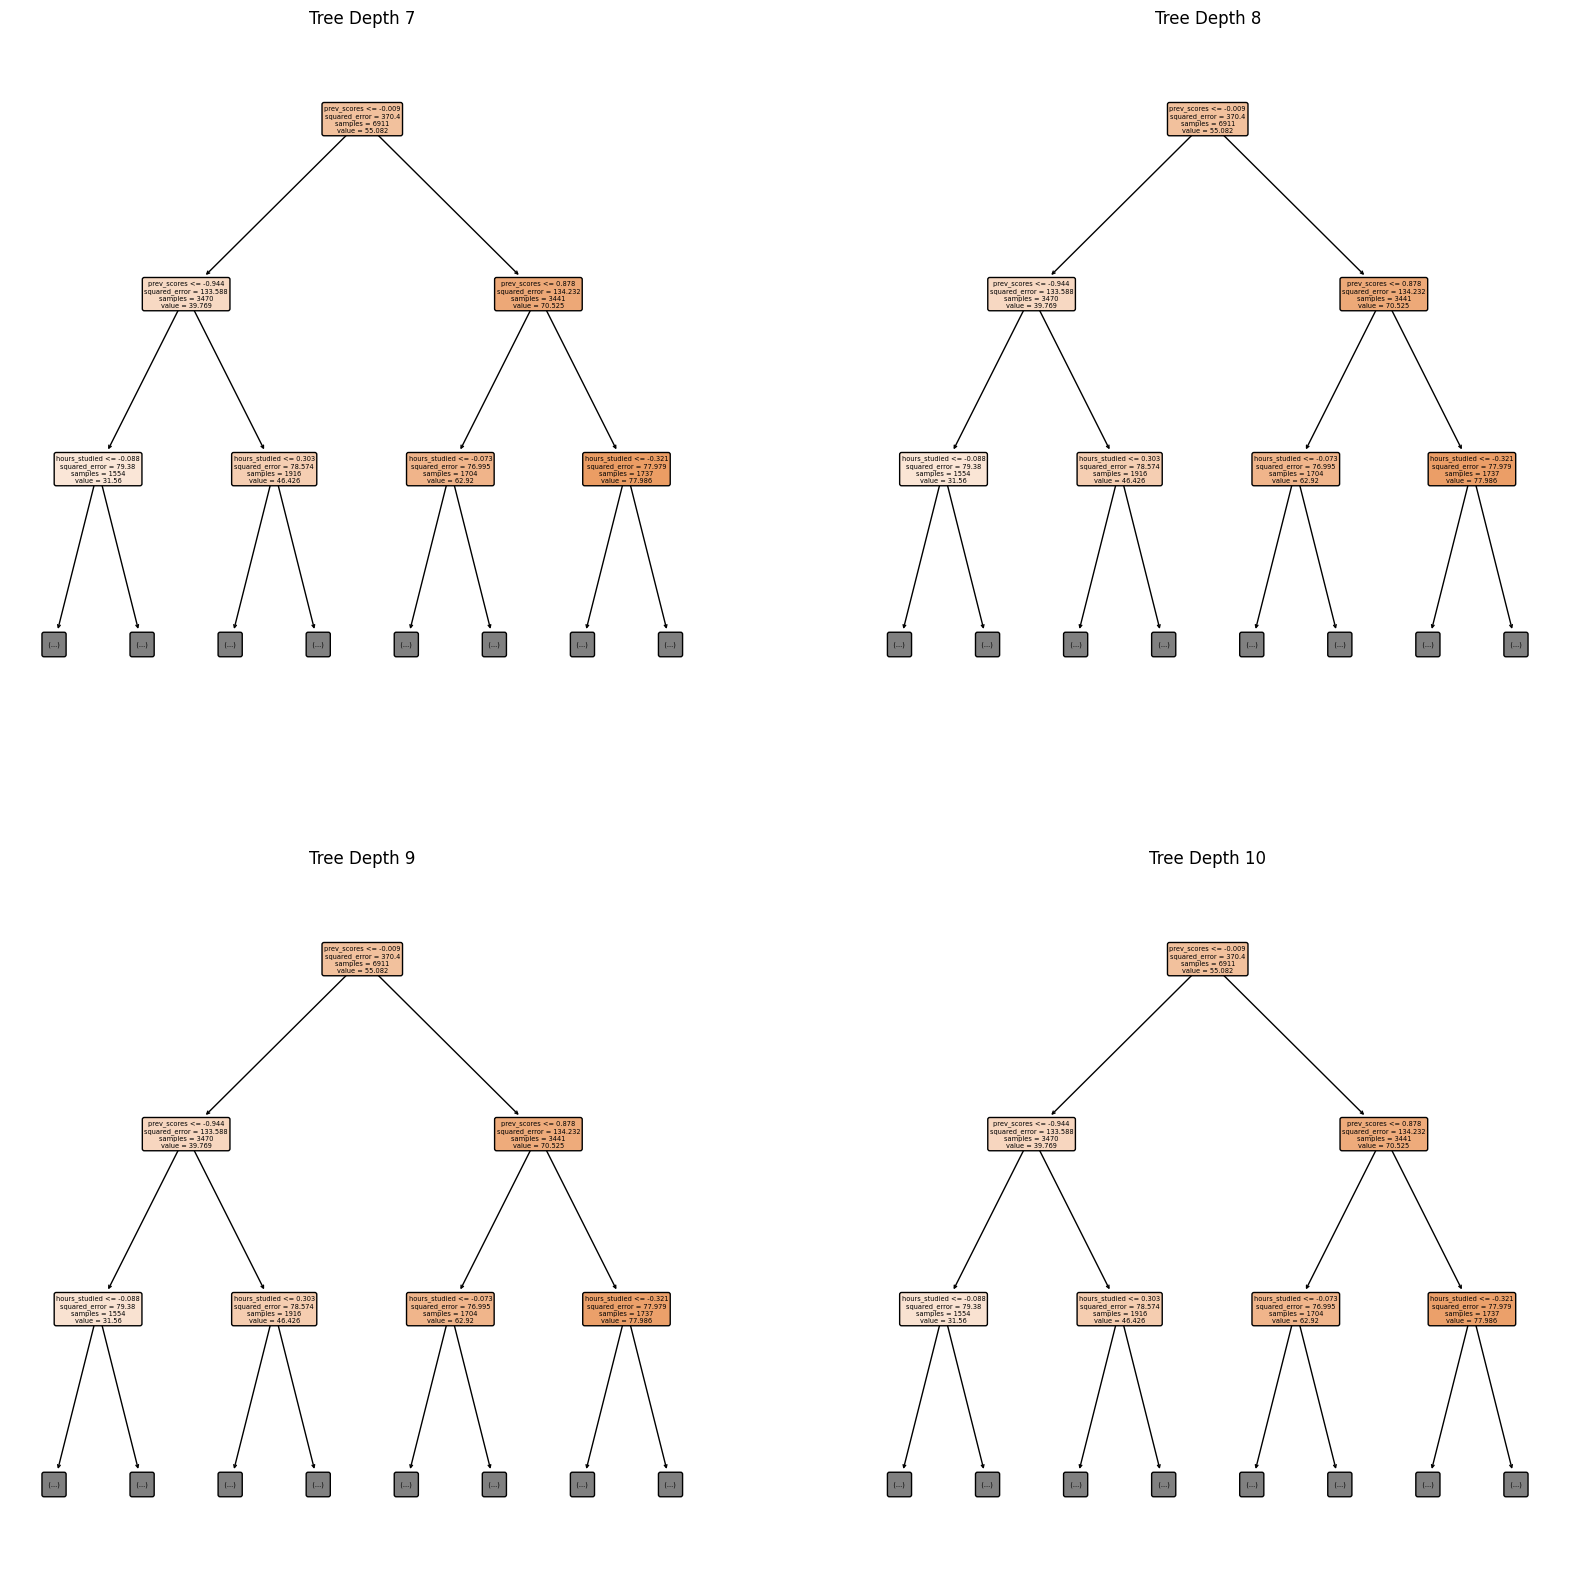

In [66]:
depths = [7, 8, 9, 10]

trees_noisy = []
for d in depths:
    print(f"Noisy Tree Depth {d}")
    dt = DecisionTreeRegressor(max_depth=d, random_state=42)
    dt.fit(X_train_noisy, y_train)
    trees_noisy.append(dt)
    
    y_pred_train_n = dt.predict(X_train_noisy)
    calculate_metrics(y_train, y_pred_train_n, "Train")
    
    y_pred_val_n = dt.predict(X_val_noisy)
    calculate_metrics(y_val, y_pred_val_n, "Val")


plt.figure(figsize=(20, 20))
for i, dt in enumerate(trees_noisy):
    plt.subplot(2, 2, i+1)
    plot_tree(dt, feature_names=X.columns, filled=True, rounded=True, max_depth=2)
    plt.title(f"Tree Depth {depths[i]}")
plt.show()

The best model here is for depth 8, as it yields the lowest validation errors (MAE of 2.28, RMSE of 2.87) and the highest validation R^2 (0.9772).
As we move to depths 9 and 10, the model begins to overfit, which is clear because the training metrics continue to improve while the validation metrics worsen as the tree starts memorizing the added noise.

In [78]:
dt_noisy = DecisionTreeRegressor(max_depth=8, random_state=42)

dt_noisy.fit(X_train_noisy, y_train)

y_pred_test_noisy = dt_noisy.predict(X_test_noisy)
_ = calculate_metrics(y_test, y_pred_test_noisy, "Test")

Test Metrics
MAE:         2.40
MSE:         9.07
RMSE:        3.01
R2:        0.9754
------------------


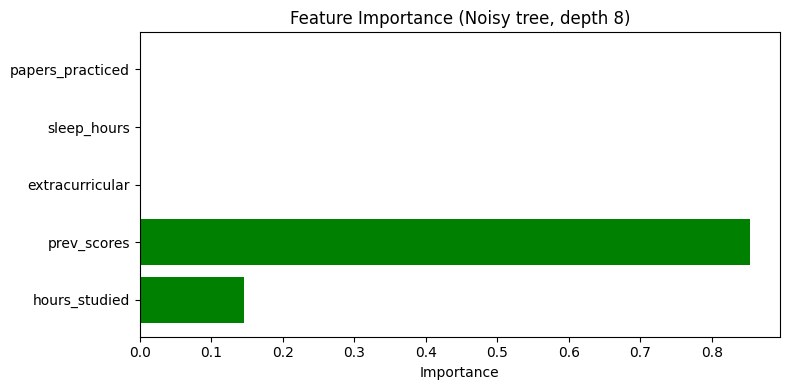

In [80]:
plt.figure(figsize=(8, 4))
plt.barh(X.columns, dt_noisy.feature_importances_, color='green')
plt.title("Feature Importance (Noisy tree, depth 8)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

Model works for test set also and the same features are important

In [74]:
# Original PCA
pca_orig = PCA(n_components=4, random_state=42)
pca_orig.fit(X_train_norm)
print("Dispersion:", np.round(pca_orig.explained_variance_ratio_, 3))

# Noisy PCA
pca_noisy = PCA(n_components=4, random_state=42)
X_train_noisy_pca = pca_noisy.fit_transform(X_train_noisy)

# Reconstruction
X_train_denoised = pca_noisy.inverse_transform(X_train_noisy_pca)

X_val_noisy_pca = pca_noisy.transform(X_val_noisy)
X_val_denoised = pca_noisy.inverse_transform(X_val_noisy_pca)

X_test_noisy_pca = pca_noisy.transform(X_test_noisy)
X_test_denoised = pca_noisy.inverse_transform(X_test_noisy_pca)

Dispersion: [0.205 0.204 0.201 0.196]


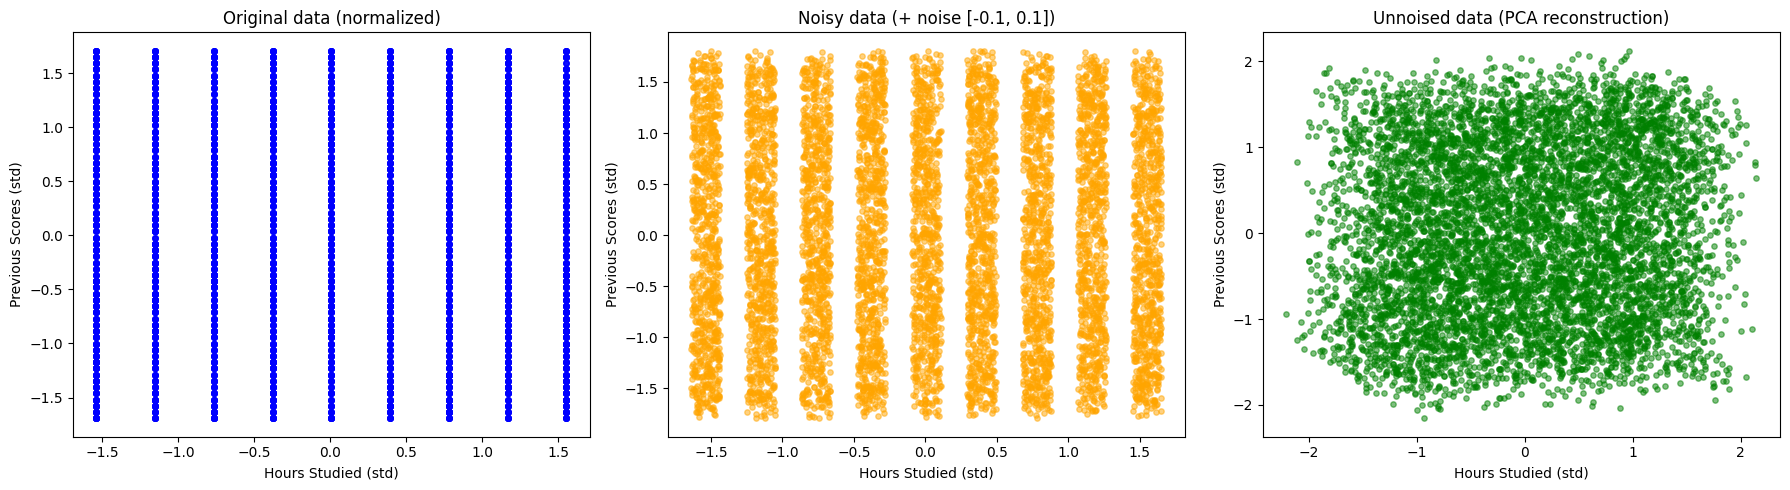

In [75]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.scatter(X_train_norm.iloc[:, 0], X_train_norm.iloc[:, 1], alpha=0.5, color='blue', s=15)
plt.title("Original data (normalized)")
plt.xlabel("Hours Studied (std)")
plt.ylabel("Previous Scores (std)")

plt.subplot(1, 3, 2)
plt.scatter(X_train_noisy.iloc[:, 0], X_train_noisy.iloc[:, 1], alpha=0.5, color='orange', s=15)
plt.title("Noisy data (+ noise [-0.1, 0.1])")
plt.xlabel("Hours Studied (std)")
plt.ylabel("Previous Scores (std)")

plt.subplot(1, 3, 3)
plt.scatter(X_train_denoised[:, 0], X_train_denoised[:, 1], alpha=0.5, color='green', s=15)
plt.title("Unnoised data (PCA reconstruction)")
plt.xlabel("Hours Studied (std)")
plt.ylabel("Previous Scores (std)")

plt.tight_layout()
plt.show()

Array [0.205 0.204 0.201 0.196] represents the explained variance ratio. In a successful PCA setup, the first few components capture the vast majority of the variance (e.g., 80%, 15%, 3%, etc.), allowing to drop the lowest-variance components under the assumption that they are just noise.

Here all 5 dimensions carry almost exactly the same amount of variance (~20% each). There is no clear primary direction in the data. Because the variance is perfectly balanced across all features, dropping even a single component (by using n_components=4) doesn't just remove the artificial noise, it throws away critical structural information.

When the algorithm tries to project the 4-dimensional data back into 5 dimensions, the strict geometric relationship that created those discrete vertical lines is permanently broken, resulting in the scattered green plot.

Denoised Tree Depth 7
Train Metrics
MAE:         2.28
MSE:         8.21
RMSE:        2.87
R2:        0.9778
------------------
Val Metrics
MAE:         2.60
MSE:        10.51
RMSE:        3.24
R2:        0.9709
------------------
Denoised Tree Depth 8
Train Metrics
MAE:         2.00
MSE:         6.38
RMSE:        2.53
R2:        0.9828
------------------
Val Metrics
MAE:         2.50
MSE:         9.78
RMSE:        3.13
R2:        0.9729
------------------
Denoised Tree Depth 9
Train Metrics
MAE:         1.72
MSE:         4.87
RMSE:        2.21
R2:        0.9869
------------------
Val Metrics
MAE:         2.46
MSE:         9.49
RMSE:        3.08
R2:        0.9737
------------------
Denoised Tree Depth 10
Train Metrics
MAE:         1.42
MSE:         3.54
RMSE:        1.88
R2:        0.9904
------------------
Val Metrics
MAE:         2.43
MSE:         9.67
RMSE:        3.11
R2:        0.9732
------------------


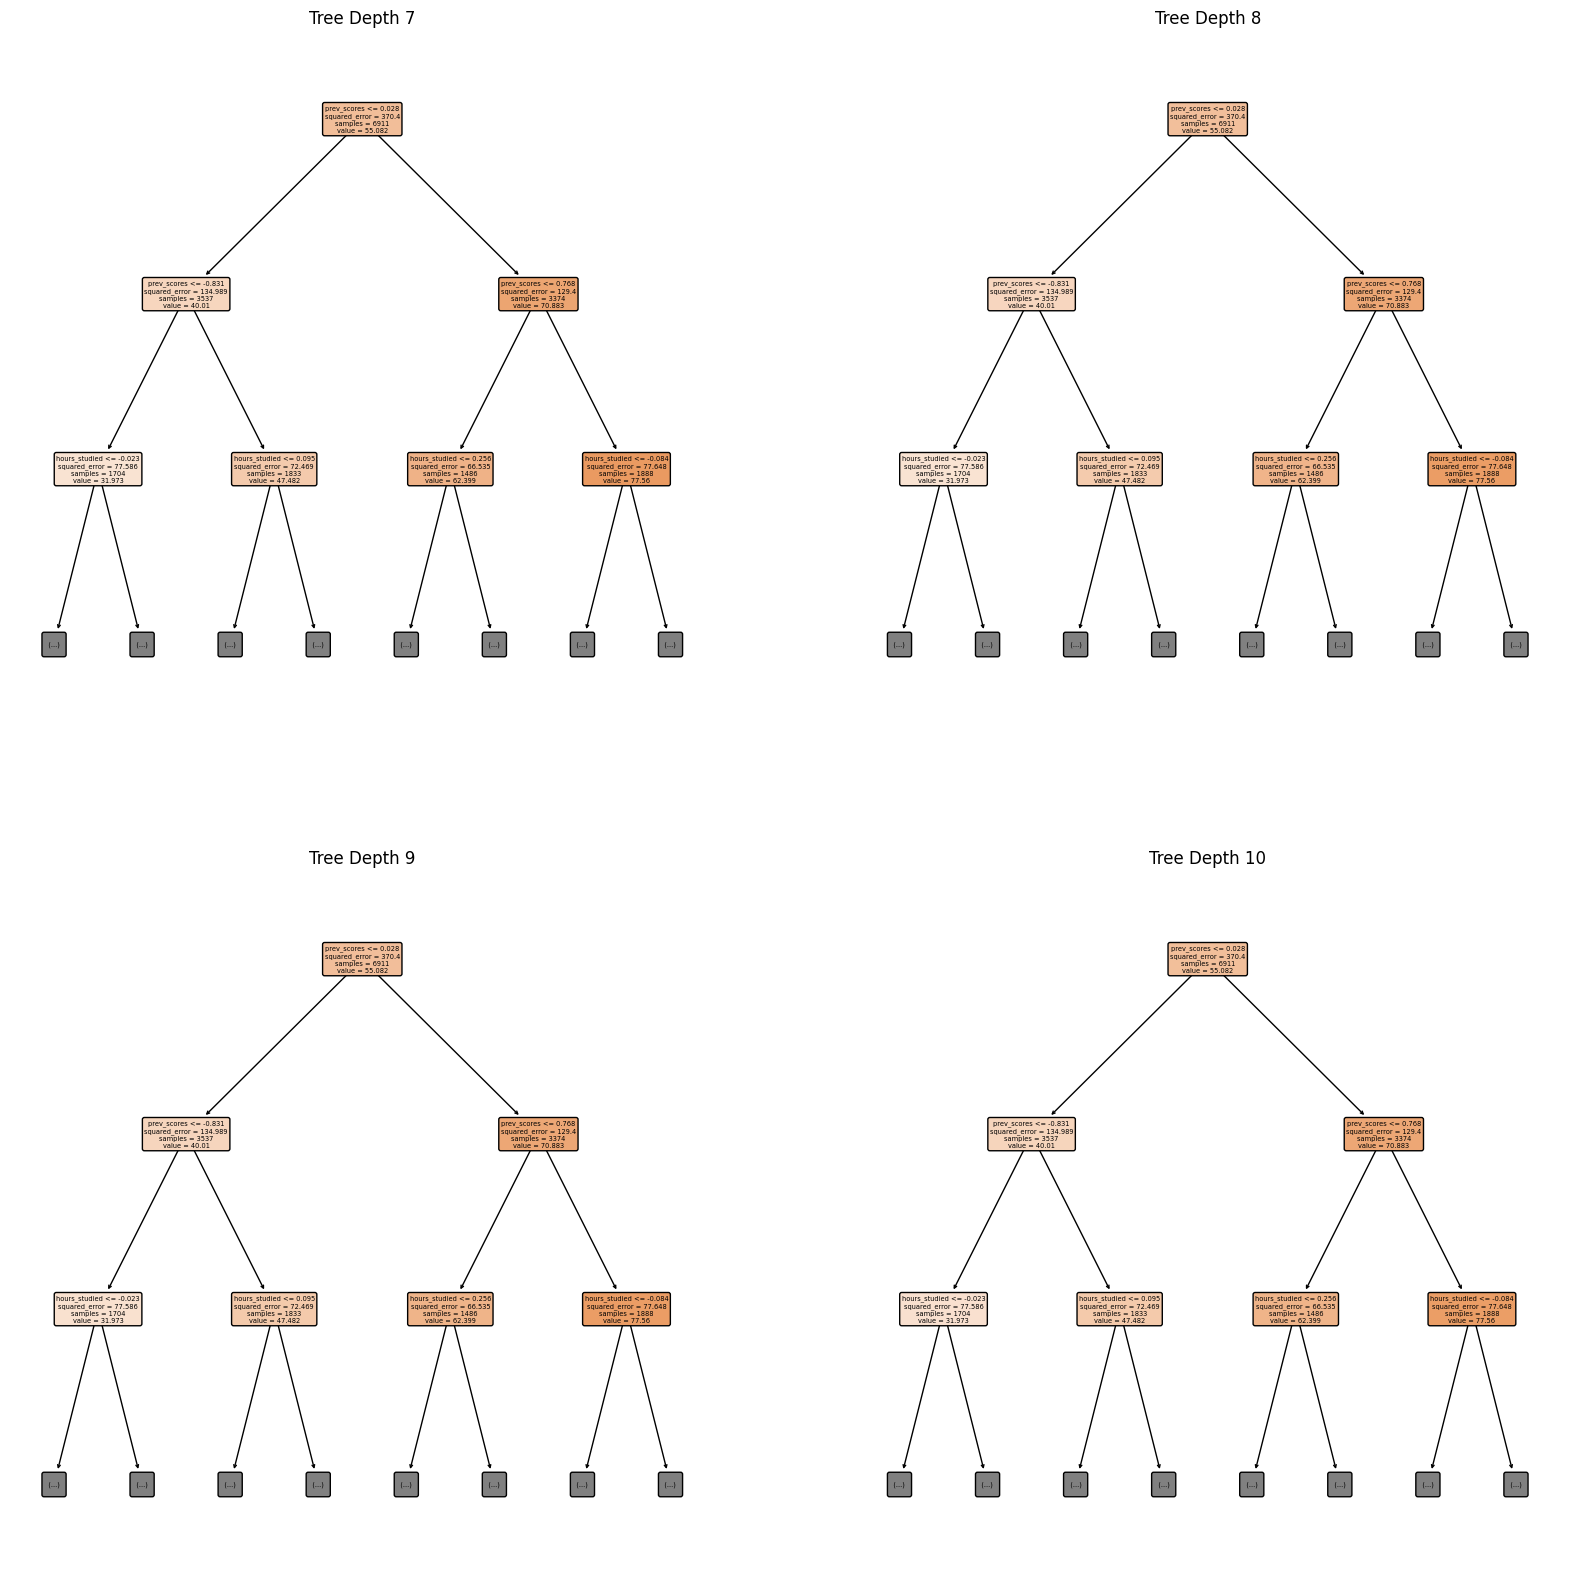

In [76]:
trees_denoised = []
for d in depths:
    print(f"Denoised Tree Depth {d}")
    dt = DecisionTreeRegressor(max_depth=d, random_state=42)
    dt.fit(X_train_denoised, y_train)
    trees_denoised.append(dt)
    
    y_pred_train_dn = dt.predict(X_train_denoised)
    calculate_metrics(y_train, y_pred_train_dn, "Train")
    
    y_pred_val_dn = dt.predict(X_val_denoised)
    calculate_metrics(y_val, y_pred_val_dn, "Val")
    
plt.figure(figsize=(20, 20))
for i, dt in enumerate(trees_denoised):
    plt.subplot(2, 2, i+1)
    plot_tree(dt, feature_names=X.columns, filled=True, rounded=True, max_depth=2)
    plt.title(f"Tree Depth {depths[i]}")
plt.show()

In [79]:
dt_denoised = DecisionTreeRegressor(max_depth=8, random_state=42)

dt_denoised.fit(X_train_denoised, y_train)

y_pred_test_denoised = dt_denoised.predict(X_test_denoised)
_ = calculate_metrics(y_test, y_pred_test_denoised, "Test")

Test Metrics
MAE:         2.56
MSE:        10.35
RMSE:        3.22
R2:        0.9720
------------------


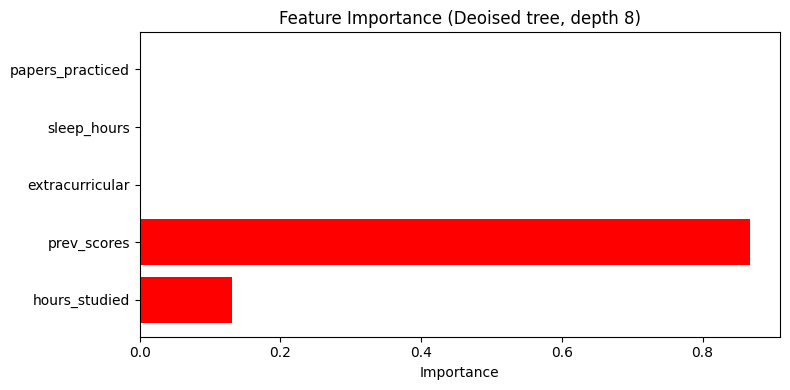

In [81]:
plt.figure(figsize=(8, 4))
plt.barh(X.columns, dt_denoised.feature_importances_, color='red')
plt.title("Feature Importance (Deoised tree, depth 8)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

Despite the significant loss of structural data integrity following the PCA reconstruction (as visually confirmed by the scatter plots), the decision tree models demonstrated impressive resilience. The accuracy on the validation set for the tree with a depth of 8 ($R^2 \approx 0.9729$) remained practically at the same level as the results for both the original and the noisy data. This highlights the unique nature of decision trees: because the algorithm searches for optimal split points rather than linear dependencies, it successfully adapted to the blurred reconstructed features and still managed to extract the target variable's underlying signal. Nevertheless, PCA did not prove to be an effective tool for classical denoising of linearly independent tabular data. Instead of merely filtering out the noise, it caused a complex geometric transformation that compromised the original features.